# Exploration des datasets

In [96]:
#pip install pandas

## Traitement de la base de données des CV

In [97]:
import pandas as pd
import os
print(os.path.exists("./resume-huggingface.jsonl"))  # doit retourner True

df_3 = pd.read_json("./resume-huggingface.jsonl", lines=True)
df_3

True


,personal_info,experience,education,skills,projects,certifications,achievements,workshops,publications,teaching_experience,internships
0,"{'name': 'Unknown', 'email': 'Unknown', 'phone...","[{'company': 'Fresher', 'company_info': {'indu...","[{'degree': {'level': 'ME', 'field': 'Computer...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Unknown', 'description': 'Unknown',...",,NaN,NaN,NaN,NaN,NaN
1,"{'name': 'Unknown', 'email': 'Unknown', 'phone...","[{'company': 'Delta Controls, Dubai FZCO', 'co...","[{'degree': {'level': 'B.E', 'field': 'Electro...",{'technical': {'project_management': [{'name':...,"[{'name': 'FGP/WPMP', 'description': 'Led syst...",,NaN,NaN,NaN,NaN,NaN
2,"{'name': 'Not Provided', 'email': 'Not Provide...","[{'company': 'Parkar Consulting and Labs', 'co...","[{'degree': {'level': 'B.E.', 'field': 'Not Pr...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'FPGA Implementation', 'description'...",,NaN,NaN,NaN,NaN,NaN
3,"{'name': 'Unknown', 'email': 'Unknown', 'phone...","[{'company': 'Delta Controls, Dubai FZCO', 'co...","[{'degree': {'level': 'B.E', 'field': 'Electro...",{'technical': {'project_management': [{'name':...,"[{'name': 'FGP/WPMP', 'description': 'Led syst...",,NaN,NaN,NaN,NaN,NaN
4,"{'name': '', 'email': '', 'phone': '', 'locati...","[{'company': 'Atos Syntel', 'company_info': {'...",[{'degree': {'level': 'Bachelor of Engineering...,{'technical': {'programming_languages': [{'nam...,[],"{""name"": ""ESD Program"", ""issuer"": ""Zensar Tech...","[Treasurer in IEEE student branch at JSCOE, Pu...","[{'name': 'Medical IoT', 'issuer': 'IEEE Stand...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4812,"{'name': 'Patricia Pratt', 'email': 'nthomas@e...","[{'company': 'Palmer-Bass', 'company_info': {'...","[{'degree': {'level': 'BSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",,NaN,NaN,NaN,NaN,NaN
4813,"{'name': 'Paul Ferguson', 'email': 'fletcherje...","[{'company': 'Williams Inc', 'company_info': {...","[{'degree': {'level': 'MSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",,NaN,NaN,NaN,NaN,NaN
4814,"{'name': 'Amy Blackwell', 'email': 'thall@exam...","[{'company': 'Riggs, Gonzales and Brooks', 'co...","[{'degree': {'level': 'BSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",,NaN,NaN,NaN,NaN,NaN
4815,"{'name': 'Andrew Brown', 'email': 'debra88@exa...","[{'company': 'Robinson-Reed', 'company_info': ...","[{'degree': {'level': 'MSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",,NaN,NaN,NaN,NaN,NaN


In [98]:
#check duplicates
personal_df = pd.json_normalize(df_3["personal_info"])
print(personal_df.duplicated(subset=['summary']).sum())
personal_df[personal_df.duplicated(subset=['summary'], keep=False)]

3906


,name,email,phone,summary,linkedin,github,location.city,location.country,location.remote_preference
1,Unknown,Unknown,Unknown,Experienced Operations Manager with expertise ...,NaN,NaN,Pune,India,Unknown
3,Unknown,Unknown,Unknown,Experienced Operations Manager with expertise ...,NaN,NaN,Pune,India,Unknown
4,,,,,,,Pune,India,
5,,,,,,,Pune,Maharashtra,
6,,,,,,,Nagpur,India,
...,...,...,...,...,...,...,...,...,...
4812,Patricia Pratt,nthomas@example.org,+1-789-612-6930x4273,Strategic Solutions Architect with experience ...,linkedin.com/in/woodardryan,github.com/brandon28,Lake Mark,India,hybrid
4813,Paul Ferguson,fletcherjeremy@example.net,382.974.4937x589,Strategic Solutions Architect with experience ...,linkedin.com/in/ashleygonzalez,github.com/elliottcorey,West Rachael,Trinidad and Tobago,hybrid
4814,Amy Blackwell,thall@example.net,2143612884,Strategic Solutions Architect with experience ...,linkedin.com/in/clifford80,github.com/angel76,West Samantha,Anguilla,remote
4815,Andrew Brown,debra88@example.com,973.404.4501,Strategic Solutions Architect with experience ...,linkedin.com/in/melissa61,github.com/smithbrittney,South Thomasmouth,Saint Martin,onsite


Comme la base de données est construite d'une telle manière que plusieures personnes peuvent se partager la même description, nous avons décidé de ne pas supprimer les CV qui continnent la même description.

In [99]:
df_3.personal_info[0]

{'name': 'Unknown',
 'email': 'Unknown',
 'phone': 'Unknown',
 'location': {'city': 'Pune',
  'country': 'India',
  'remote_preference': 'Unknown'},
 'summary': 'Python Developer with experience in Python, Tensorflow, Numpy, C, C++, MySQL, and various platforms.',
 'linkedin': 'Unknown',
 'github': 'Unknown'}

In [100]:
#nous retenons que le remote_preference et summary des personal infos
personal_df = pd.json_normalize(df_3["personal_info"])
personal_df = personal_df[['name', 'summary', 'location.remote_preference']]

In [101]:
cv = pd.concat([personal_df,df_3.drop(columns=['personal_info'])], axis=1)
cv=cv.drop(columns=['teaching_experience','publications','workshops','achievements'])

In [102]:
cv["internships"].notna().value_counts()
#donc cette information n'est pas très pertinente, on va enlever la colonne
cv = cv.drop(columns=["internships"])

In [103]:
cv = cv.drop(cv[cv["name"].astype(str).isin(["Unknown", "Not Provided",""])].index)
cv = cv.reset_index(drop=True)
cv

,name,summary,location.remote_preference,experience,education,skills,projects,certifications
0,Fahed,IABAC Certified Data Scientist with versatile ...,NaN,"[{'company': 'Datamites', 'title': 'Data Scien...","[{'degree': {'level': 'B. Tech', 'field': 'Com...",{'technical': {'programming_languages': [{'nam...,[],
1,Fahed,IABAC Certified Data Scientist with versatile ...,NaN,"[{'company': 'Datamites', 'title': 'Data Scien...","[{'degree': {'level': 'B. Tech', 'field': 'Com...",{'technical': {'programming_languages': [{'nam...,[],
2,Artem Sliusarenko,"Final year Computer Science student at City, U...",hybrid,"[{'company': 'AT&T', 'company_info': {'industr...","[{'degree': {'level': 'Bachelor', 'field': 'Co...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Thunderbird program', 'description'...",
3,Newcomer Indian Advocate,A Microsoft Certified Systems Engineer and Adv...,NaN,"[{'company': 'District Courts', 'title': 'Advo...","[{'degree': {'level': 'Bachelor's', 'field': '...","{'technical': {'programming_languages': [], 'f...",[],
4,Artem Sliusarenko,"Final year Computer Science student at City, U...",hybrid,"[{'company': 'TechStart AI', 'company_info': {...","[{'degree': {'level': 'BSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Resume Parser & Job Matcher', 'desc...",
...,...,...,...,...,...,...,...,...
4617,Patricia Pratt,Strategic Solutions Architect with experience ...,hybrid,"[{'company': 'Palmer-Bass', 'company_info': {'...","[{'degree': {'level': 'BSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",
4618,Paul Ferguson,Strategic Solutions Architect with experience ...,hybrid,"[{'company': 'Williams Inc', 'company_info': {...","[{'degree': {'level': 'MSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",
4619,Amy Blackwell,Strategic Solutions Architect with experience ...,remote,"[{'company': 'Riggs, Gonzales and Brooks', 'co...","[{'degree': {'level': 'BSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",
4620,Andrew Brown,Strategic Solutions Architect with experience ...,onsite,"[{'company': 'Robinson-Reed', 'company_info': ...","[{'degree': {'level': 'MSc', 'field': 'Compute...",{'technical': {'programming_languages': [{'nam...,"[{'name': 'Solutions Architect Project', 'desc...",


In [104]:
cv['experience'][2]

[{'company': 'AT&T',
  'company_info': {'industry': 'Telecommunications', 'size': '80+ employees'},
  'title': 'Project Manager',
  'level': 'manager',
  'employment_type': 'full-time',
  'dates': {'start': '2013-01-01',
   'end': '2024-03-20',
   'duration': '11 years 2 months'},
  'responsibilities': ['Manage and lead all aspects of Transition / Pre-Transition comprising multiple vendors',
   'Transition Drill down sessions, Forward/Reverse Shadow phases and Reverse Presentation',
   'Transition Documentation & signoff of SMP & System Appreciation Document etc',
   'Measure & track testing metrics scorecard as part of Vendor Quality Index (VQI) initiative of AT&T',
   'Measure and track operating metrics like Onsite Subcon Index, Offshoring Index, Leakage Index, Utilization Index and Tail Index',
   'Manage, Track and Submit Project Monthly Financials & Invoicing',
   "Ensure 100% compliance to client / organization's quality and security processes, policies and SLAs",
   'Plan, mana

In [105]:
#La colonne 'projects' est enregistrée comme une liste de dictionnaires
cv["projects"][2]

[{'name': 'Thunderbird program',
  'description': "One-Stop-Test-Shop catering to AT&T's Enterprise-wide business critical applications. As part of this Fixed Price engagement various types of testing like System, Regression, Sanity and UAT support gets executed through Agile Methodologies on applications under Billing and Sales domain.",
  'technologies': ['Python',
   'Selenium',
   'RALLY / IBM TD Platform',
   'DevOps / DevSecOps',
   'SAFe - Agile Craft',
   'Visual Basic 6.0',
   'MS-SQL Server / Oracle 8/8i',
   'Conformiq',
   'HP QC / QTP',
   'Crystal Report 8.5'],
  'role': 'Project Manager',
  'url': 'github.com/artemslius/resume-parser-matcher',
  'impact': 'Achieved 85% accuracy in job-candidate matching'}]

In [106]:
cv['education'][0]

[{'degree': {'level': 'B. Tech', 'field': 'Computer Science & Engineering'},
  'institution': {'name': 'Indo Global College of Engineering',
   'location': 'Mohali, Punjab'},
  'dates': {'start': '2017-01'}}]

In [107]:
cv['skills'][1]

{'technical': {'programming_languages': [{'name': 'Python', 'level': 'expert'},
   {'name': 'R Studio', 'level': 'intermediate'}],
  'frameworks': [{'name': 'Machine Learning', 'level': 'advanced'},
   {'name': 'Data Visualization', 'level': 'advanced'},
   {'name': 'Tableau', 'level': 'advanced'}],
  'databases': [],
  'cloud': []},
 'languages': []}

In [108]:
#on remarque des descriptions fictives
cv.iloc[958]["summary"]

'Gun whose ever feeling prove Republican cup. Sometimes any despite stuff what record fight. Mrs watch well grow agree work politics deep.'

In [109]:
# Construction de la colonne cv_text qui sera utilisée par notre réseau de neuones
import ast
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

#suppression des mots vides en anglais
STOPWORDS = set(list(ENGLISH_STOP_WORDS)) - {"not", "no", "nor"}

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r"(\'re)", " are", text) #transforme "you're" en "you are"
    text = re.sub(r"(\'s)", " is", text)
    text = re.sub(r"(\'ve)", " have", text)
    text = re.sub(r"(n\'t)", " not", text) # transforme "don't" en "do not"
    text = re.sub(r"(\'ll)", " will", text)
    text = re.sub(r"(\'d)", " would", text)
    text = re.sub(r"(\'m)", " am", text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text) # supprimer caractères non alphabétiques
    tokens = [tok for tok in text.split() if len(tok) > 2 and tok not in STOPWORDS]
    return " ".join(tokens)

def extraire_experience(exp_list):
    if not isinstance(exp_list, list): return ""
    compagnie = []
    poste = []
    mois = 0
    respo =[]
    tech =[]

    for exp in exp_list:
        if exp.get("title") not in ["", "Unknown", None]: poste.append(exp["title"])
        if exp.get("company") not in ["", "Unknown", None]: compagnie.append(exp["company"])
        respo += exp.get("responsabilities",[]) or []
        env= exp.get("technical_environment", {})
        tech  += env.get("technologies",[]) or []
        #if exp.get("duration") not in ["", "Unknown", None]: mois.append(exp[""])

    return(
        f" titles: {', '.join(poste)}, "
        f" compagnies: {', '.join(compagnie)}, "
        f" responsabilities: {', '.join(respo)}, "
        f" technical tools: {', '.join(tech)} "
    )

def extraire_projets(proj_list):
    if not isinstance(proj_list, list): return ""

    project = []
    tools = []

    for proj in proj_list:
        if proj.get("description") not in ["", "Unknown", None]: project.append(proj["description"])
        tools += proj.get("technologies",[]) or []

    return(
        f" projects: {', '.join(project)} "
        f" and used tools: {', '. join(tools)} "
    )

def extraire_education(edu_list):
    if not isinstance(edu_list, list): return ""

    education = []
    field = []
    level = []

    for edu in edu_list:
        degree = edu.get("degree",{})
        education.append(
            " level: " + degree.get("level", "") +
            " field: " + degree.get("field", "")
        )

    return(
        f" education: {', '.join(education)} "
    )

def extraire_skills(skill_list):
  if not isinstance(skill_list, list): return ""

  tools = []

  technical = skill_list.get("technical", {})

  # Parcourir chaque catégorie technique
  for category in ["programming_languages", "frameworks", "databases", "cloud", "project_management", "software tools"]:
      items = technical.get(category, [])

      for item in items:
          name = item.get("name")
          if name not in ["", None, "Unknown"]:
              tools.append(name)

  return f" skills: {', '.join(tools)} "


def extraire_certifications(cert_list):
    if not isinstance(cert_list, list):
        return ""

    certifications = []

    for cert in cert_list:

        name = cert.get("name")
        if name not in ["", None, "Unknown"]:
            certifications.append(name)

    return f" certifications: {', '.join(certifications)} "

#remplacer les nan de la colonne remote_preference
cv['location.remote_preference'] = cv['location.remote_preference'].fillna("no preference")

cv["cv_text"] = (" experiences: " + cv["experience"].apply(extraire_experience) + cv["projects"].apply(extraire_projets)) + cv['education'].apply(extraire_education) + cv["skills"].apply(extraire_skills) + cv["certifications"].apply(extraire_certifications) + " location preference : " + cv["location.remote_preference"]


In [110]:
cv=cv.drop(columns=['projects','education','skills', "experience", "certifications", "location.remote_preference"])

In [111]:
cv

,name,summary,cv_text
0,Fahed,IABAC Certified Data Scientist with versatile ...,experiences: titles: Data Science Consultant...
1,Fahed,IABAC Certified Data Scientist with versatile ...,experiences: titles: Data Science Consultant...
2,Artem Sliusarenko,"Final year Computer Science student at City, U...","experiences: titles: Project Manager, compa..."
3,Newcomer Indian Advocate,A Microsoft Certified Systems Engineer and Adv...,"experiences: titles: Advocate, compagnies: ..."
4,Artem Sliusarenko,"Final year Computer Science student at City, U...",experiences: titles: Machine Learning Engine...
...,...,...,...
4617,Patricia Pratt,Strategic Solutions Architect with experience ...,"experiences: titles: Solutions Architect, c..."
4618,Paul Ferguson,Strategic Solutions Architect with experience ...,"experiences: titles: Solutions Architect, So..."
4619,Amy Blackwell,Strategic Solutions Architect with experience ...,"experiences: titles: Solutions Architect, So..."
4620,Andrew Brown,Strategic Solutions Architect with experience ...,"experiences: titles: Solutions Architect, c..."


In [112]:
cv["cv_text"][23]

' experiences:  titles: Python Developer,  compagnies: Guzman Inc,  responsabilities: ,  technical tools: Git, REST, CI/CD  projects: Developed a robust RESTful API using Flask and integrated it with cloud services, resulting in improved data processing and scalability.  and used tools: Kubernetes, C++, REST  education:  level: MSc field: Computer Science,  level: BSc field: Computer Science  location preference : remote'

In [113]:
cv['cv_text'][2]

" experiences:  titles: Project Manager,  compagnies: AT&T,  responsabilities: ,  technical tools: Python, Selenium, RALLY / IBM TD Platform, DevOps / DevSecOps, SAFe - Agile Craft, Visual Basic 6.0, MS-SQL Server / Oracle 8/8i, Conformiq, HP QC / QTP, Crystal Report 8.5  projects: One-Stop-Test-Shop catering to AT&T's Enterprise-wide business critical applications. As part of this Fixed Price engagement various types of testing like System, Regression, Sanity and UAT support gets executed through Agile Methodologies on applications under Billing and Sales domain.  and used tools: Python, Selenium, RALLY / IBM TD Platform, DevOps / DevSecOps, SAFe - Agile Craft, Visual Basic 6.0, MS-SQL Server / Oracle 8/8i, Conformiq, HP QC / QTP, Crystal Report 8.5  education:  level: Bachelor field: Commerce  location preference : hybrid"

In [114]:
#On veut garder que les offres tech, car les CV dont on dispose ont des profils tech
print(len(cv))
print(cv["summary"].nunique())
#Comme les CV ont été artifficiellment générés, nous allons garder seulement 1 de chaque differente description.
cv2 = cv.drop_duplicates(subset='summary')
cv2

4622
846


,name,summary,cv_text
0,Fahed,IABAC Certified Data Scientist with versatile ...,experiences: titles: Data Science Consultant...
2,Artem Sliusarenko,"Final year Computer Science student at City, U...","experiences: titles: Project Manager, compa..."
3,Newcomer Indian Advocate,A Microsoft Certified Systems Engineer and Adv...,"experiences: titles: Advocate, compagnies: ..."
6,Yogesh Tikhat,Experienced Database Administrator with expert...,"experiences: titles: Database Administrator,..."
11,NaN,NaN,"experiences: titles: Data Scientist, compag..."
...,...,...,...
4122,Jennifer Mercer,Embedded Systems Engineer with experience in d...,experiences: titles: Embedded Systems Engine...
4222,Richard Campbell,Quality Assurance Engineer with extensive expe...,"experiences: titles: Qa Engineer, Qa Enginee..."
4322,Kristy Williams,Automation Engineer with expertise in designin...,"experiences: titles: Automation Engineer, c..."
4422,Gina Fleming,Technical Architect with a focus on designing ...,"experiences: titles: Technical Architect, c..."


On ne retient que 847 CV sur les 4622.

In [115]:
cv2

,name,summary,cv_text
0,Fahed,IABAC Certified Data Scientist with versatile ...,experiences: titles: Data Science Consultant...
2,Artem Sliusarenko,"Final year Computer Science student at City, U...","experiences: titles: Project Manager, compa..."
3,Newcomer Indian Advocate,A Microsoft Certified Systems Engineer and Adv...,"experiences: titles: Advocate, compagnies: ..."
6,Yogesh Tikhat,Experienced Database Administrator with expert...,"experiences: titles: Database Administrator,..."
11,NaN,NaN,"experiences: titles: Data Scientist, compag..."
...,...,...,...
4122,Jennifer Mercer,Embedded Systems Engineer with experience in d...,experiences: titles: Embedded Systems Engine...
4222,Richard Campbell,Quality Assurance Engineer with extensive expe...,"experiences: titles: Qa Engineer, Qa Enginee..."
4322,Kristy Williams,Automation Engineer with expertise in designin...,"experiences: titles: Automation Engineer, c..."
4422,Gina Fleming,Technical Architect with a focus on designing ...,"experiences: titles: Technical Architect, c..."


## Traitement de la base de données des offres d'emploi

In [116]:
job = pd.read_csv("./training_data.csv")
job

,company_name,job_description,position_title,description_length,model_response
0,Google,minimum qualifications\nbachelors degree or eq...,Sales Specialist,2727,"{\n ""Core Responsibilities"": ""Responsible fo..."
1,Apple,description\nas an asc you will be highly infl...,Apple Solutions Consultant,828,"{\n ""Core Responsibilities"": ""as an asc you ..."
2,Netflix,its an amazing time to be joining netflix as w...,Licensing Coordinator - Consumer Products,3205,"{\n ""Core Responsibilities"": ""Help drive bus..."
3,Robert Half,description\n\nweb designers looking to expand...,Web Designer,2489,"{\n ""Core Responsibilities"": ""Designing webs..."
4,TrackFive,at trackfive weve got big goals were on a miss...,Web Developer,3167,"{\n ""Core Responsibilities"": ""Build and layo..."
...,...,...,...,...,...
848,Menards,job description\n\nparttime\n\nmake big money ...,Management Internship,1122,"{\n ""Core Responsibilities"": ""Responsibiliti..."
849,Parker,responsibilities\nparkers internship program w...,Human Resources Internship - Corporate (Year-...,3840,"{\n ""Core Responsibilities"": ""Assist in gene..."
850,Borgen Project,the borgen project is an innovative national ...,Writer / Journalist Internship,897,"{\n ""Core Responsibilities"": ""Write one arti..."
851,Wyndham Destinations,put the world on vacation\n\nat wyndham destin...,Inbound Customer Service / Sales (Remote),4604,"{\n ""Core Responsibilities"": ""Answer inbound..."


In [117]:
job = job.drop(columns=["description_length","model_response"])
job["job_description"] = job["job_description"].apply(preprocess_text)

In [118]:
job["job_description"][0]

'minimum qualifications bachelors degree equivalent practical experience years experience saas productivity tools businessexperience managing enterprise accounts sales cycles preferred qualifications years experience building strategic business partnerships enterprise customersability work reseller ecosystem scale businessability plan pitch execute territory business strategyability build relationships deliver results crossfunctionalmatrixed environmentability identify crosspromoting uppromoting opportunities existing account baseexcellent account management writtenverbal communication strategic analyticalthinking skills job member google cloud team inspire leading companies schools government agencies work smarter google tools like google workspace search chrome advocate innovative power products make organizations productive collaborative mobile guiding light doing whats right customer meet customers exactly provide best solutions innovation using passion google products help spread 

In [119]:
job["job_description"][0]

'minimum qualifications bachelors degree equivalent practical experience years experience saas productivity tools businessexperience managing enterprise accounts sales cycles preferred qualifications years experience building strategic business partnerships enterprise customersability work reseller ecosystem scale businessability plan pitch execute territory business strategyability build relationships deliver results crossfunctionalmatrixed environmentability identify crosspromoting uppromoting opportunities existing account baseexcellent account management writtenverbal communication strategic analyticalthinking skills job member google cloud team inspire leading companies schools government agencies work smarter google tools like google workspace search chrome advocate innovative power products make organizations productive collaborative mobile guiding light doing whats right customer meet customers exactly provide best solutions innovation using passion google products help spread 

In [120]:
job["job_text"] = "position title: " + job["position_title"] + " company name: " + job["company_name"] + " job description: " + job["job_description"]

In [121]:
job

,company_name,job_description,position_title,job_text
0,Google,minimum qualifications bachelors degree equiva...,Sales Specialist,position title: Sales Specialist company name:...
1,Apple,description asc highly influential growing min...,Apple Solutions Consultant,position title: Apple Solutions Consultant com...
2,Netflix,amazing time joining netflix continue transfor...,Licensing Coordinator - Consumer Products,position title: Licensing Coordinator - Consum...
3,Robert Half,description web designers looking expand profe...,Web Designer,position title: Web Designer company name: Rob...
4,TrackFive,trackfive weve got big goals mission revolutio...,Web Developer,position title: Web Developer company name: Tr...
...,...,...,...,...
848,Menards,job description parttime make big money menard...,Management Internship,position title: Management Internship company ...
849,Parker,responsibilities parkers internship program es...,Human Resources Internship - Corporate (Year-...,position title: Human Resources Internship - C...
850,Borgen Project,borgen project innovative national campaign wo...,Writer / Journalist Internship,position title: Writer / Journalist Internship...
851,Wyndham Destinations,world vacation wyndham destinations mission si...,Inbound Customer Service / Sales (Remote),position title: Inbound Customer Service / Sal...


In [122]:
job["position_title"].values

array(['Sales Specialist', 'Apple Solutions Consultant',
       'Licensing Coordinator - Consumer Products', 'Web Designer',
       'Web Developer', 'Frontend Web Developer',
       'Remote Website Designer', 'Web Designer', 'Web Designer',
       'SR. Web Designer', 'Web Developer', 'Web Developer',
       'Senior UI Designer', 'Wordpress Web Developer', 'UI Web Designer',
       'Senior Web Designer (REMOTE)', 'Chief Executive Officer',
       'Executive Vice President & Chief Executive Officer (CEO), Medical...',
       'CEO', 'CEO', 'CEO, Positivly',
       'Chief Executive Officer - CEO Consultant',
       'Chief Executive Officer',
       'Chief Executive Officer - Healthcare - Columbus', 'CEO Coach',
       'Assistant Vice President Premier Relationship Manager',
       'Digital Marketing Specialist', 'Senior Marketing Specialist',
       'Performance Marketing Specialist, Paid Media',
       'Software Engineer - Reno, NV', 'Software Engineer',
       'Entry Level Software Engin

In [123]:
#on garde que les profils tech pour correspondre aux cv
keywords_tech = [
    "software", "developer", "engineer", "data", "analyst",
    "web", "frontend", "backend", "fullstack", "full stack",
    "systems administrator", "network", "IT", "ecommerce", "e-commerce",
    "digital marketing", "programmer", "devops", "cloud", "database"
]

def est_tech(titre):
    titre_lower = titre.lower()
    return any(kw.lower() in titre_lower for kw in keywords_tech)

df_job_tech = job[job["position_title"].apply(est_tech)]
print(f"{len(df_job_tech)} offres tech gardées sur {len(job)}")

229 offres tech gardées sur 853


In [124]:
df_job_tech

,company_name,job_description,position_title,job_text
3,Robert Half,description web designers looking expand profe...,Web Designer,position title: Web Designer company name: Rob...
4,TrackFive,trackfive weve got big goals mission revolutio...,Web Developer,position title: Web Developer company name: Tr...
5,DesignUps,designups nashville based design interactive a...,Frontend Web Developer,position title: Frontend Web Developer company...
6,"Equisolve, Inc.",position web designer responsible providing de...,Remote Website Designer,position title: Remote Website Designer compan...
7,Zander Insurance Agency,job description zander insurance group largest...,Web Designer,position title: Web Designer company name: Zan...
...,...,...,...,...
830,Goldman Sachs,global investment research macroeconomic forec...,"Global Investment Research, Equity Research, H...","position title: Global Investment Research, Eq..."
831,BGC Partners,cantor fitzgerald senior biotech equity resear...,Equity research associate,position title: Equity research associate comp...
832,Advisor Group,equity research associate biotech apply locati...,"Equity Research Associate, Biotech","position title: Equity Research Associate, Bio..."
841,Morgan Stanley,research morgan stanley investment research un...,Equity Research Biotech Associate,position title: Equity Research Biotech Associ...


In [125]:
df_job_tech["job_text"].iloc[0]

'position title: Web Designer company name: Robert Half job description: description web designers looking expand professional reach welcome robert half marketing creative start process robert half today searching highly skilled web designers experience working corporate brand standards guidelines ideal candidates advanced skills creating wireframes designing mobile applications landing pages interactive sites testing experience working various interfaces familiarity uxui design principles candidates expected strong skills adobe photoshop illustrator indesign experience html css javascript major plus familiarity content management systems highly preferred satisfying looking freelance fulltime creative opportunities working knows area expertise industry professionals robert half marketing creative team puts needs effectively represents creative talent thats kind service youll receive team robert half marketing advertising creative backgrounds just like right start ask better support tea

## Création de label de matching ou pas


In [126]:
print(f"Nombre de CV : {len(cv2)}")
print(f"Nombre d'offres : {len(df_job_tech)}")

Nombre de CV : 847
Nombre d'offres : 229


In [143]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd


# 1. Vectoriser tout le corpus ensemble
vectorizer = TfidfVectorizer()
vectorizer.fit(list(cv2["cv_text"]) + list(df_job_tech["job_text"]))

cv_vectors  = vectorizer.transform(cv2["cv_text"])
job_vectors = vectorizer.transform(df_job_tech["job_text"])

# 2. Calculer toutes les similarités (matrice N_cv x N_job)
similarity_matrix = cosine_similarity(cv_vectors, job_vectors)

# 3. Créer les paires avec labels
paires = []
for i in range(len(cv2)):
    for j in range(len(df_job_tech)):
        score = similarity_matrix[i][j]

        if score > 0.05: # le top 5% + une petite marge car on a remarqué que certains cv ne matchaient pas vrm(voir en bas les stats)
            label = 1
        elif score < 0.013: # en dessous de la médianne (voir en bas les stats)
            label = 0
        else:
            continue  # ambigu -> on jette

        paires.append({
            "cv_text":  cv2.iloc[i]["cv_text"],
            "job_text": df_job_tech.iloc[j]["job_text"],
            "label":    label
        })

df_final = pd.DataFrame(paires)

print(df_final["label"].value_counts())

label
0    94055
1     4911
Name: count, dtype: int64


Score max : 0.380
Score moyen : 0.016
Score médian : 0.013
Score 75% : 0.022
Score 90% : 0.033
Score 95% : 0.041


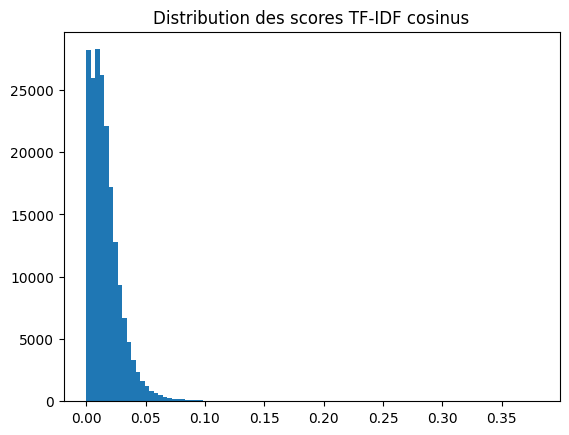

In [144]:
import matplotlib.pyplot as plt
import numpy as np

scores = similarity_matrix.flatten()
print(f"Score max : {scores.max():.3f}")
print(f"Score moyen : {scores.mean():.3f}")
print(f"Score médian : {np.median(scores):.3f}")
print(f"Score 75% : {np.percentile(scores,75):.3f}")
print(f"Score 90% : {np.percentile(scores,90):.3f}")
print(f"Score 95% : {np.percentile(scores,95):.3f}")

plt.hist(scores, bins=100)
plt.title("Distribution des scores TF-IDF cosinus")
plt.show()

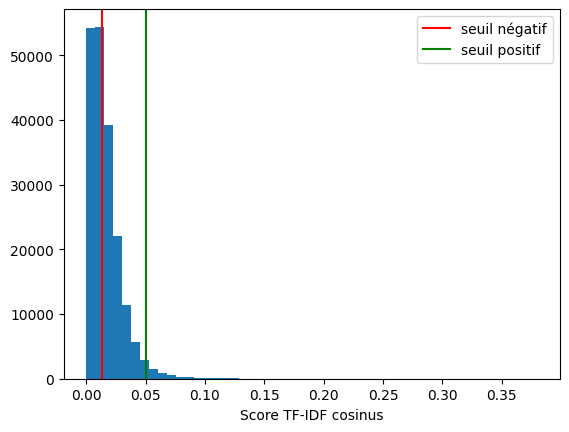

In [145]:
import matplotlib.pyplot as plt

scores = similarity_matrix.flatten()
plt.hist(scores, bins=50)
plt.axvline(x=0.013, color='r', label='seuil négatif')
plt.axvline(x=0.05, color='g', label='seuil positif')
plt.xlabel("Score TF-IDF cosinus")
plt.legend()
plt.show()

In [146]:
df_final

,cv_text,job_text,label
0,experiences: titles: Data Science Consultant...,position title: Web Designer company name: Rob...,0
1,experiences: titles: Data Science Consultant...,position title: Web Developer company name: Tr...,0
2,experiences: titles: Data Science Consultant...,position title: Frontend Web Developer company...,0
3,experiences: titles: Data Science Consultant...,position title: Remote Website Designer compan...,0
4,experiences: titles: Data Science Consultant...,position title: Web Designer company name: Zan...,0
...,...,...,...
98961,"experiences: titles: Solutions Architect, So...","position title: Global Investment Research, Eq...",0
98962,"experiences: titles: Solutions Architect, So...",position title: Equity research associate comp...,0
98963,"experiences: titles: Solutions Architect, So...","position title: Equity Research Associate, Bio...",0
98964,"experiences: titles: Solutions Architect, So...",position title: Equity Research Biotech Associ...,0


In [147]:
df_final[df_final['label']==1]

,cv_text,job_text,label
19,experiences: titles: Data Science Consultant...,position title: Supply Chain Analyst company n...,1
27,experiences: titles: Data Science Consultant...,position title: Software Developer company nam...,1
28,experiences: titles: Data Science Consultant...,position title: Senior Software Developer- Ful...,1
29,experiences: titles: Data Science Consultant...,position title: Full Stack Software Engineer c...,1
35,experiences: titles: Data Science Consultant...,position title: Sr analyst compliance company ...,1
...,...,...,...
98907,"experiences: titles: Solutions Architect, So...",position title: Data Analytics Senior Mangager...,1
98936,"experiences: titles: Solutions Architect, So...",position title: IT Systems Administrator compa...,1
98948,"experiences: titles: Solutions Architect, So...",position title: Mainframe Programmer Analyst c...,1
98954,"experiences: titles: Solutions Architect, So...",position title: Network System Administrator c...,1


In [148]:
df_pos = df_final[df_final['label']==1]
df_neg = df_final[df_final['label']==0].sample(n=len(df_pos), random_state=42) #le random state nous permet d'avoir les mêmes valeurs à chaque fois (code reproductible)

df_equilibre = pd.concat([df_pos,df_neg]).sample(frac=1,random_state=42) #frac=1 nous permet de melanger les lignes entre-elles.
print(df_equilibre["label"].value_counts())

label
0    4911
1    4911
Name: count, dtype: int64


In [149]:
# 4. Sauvegarder
df_equilibre.to_csv("dataset_final.csv", index=False)

In [150]:
# Affiche quelques paires label 1 pour vérifier
df_label1 = df_equilibre[df_equilibre["label"] == 1].head(5)
for _, row in df_label1.iterrows():
    print("CV  :", row["cv_text"][:200])
    print("JOB :", row["job_text"][:200])
    print("---")

CV  :  experiences:  titles: Web Developer, Web Developer,  compagnies: Villanueva-Henderson, Sanchez, Rice and Castro,  responsabilities: ,  technical tools: REST, GraphQL, GraphQL, Git  projects: Develope
JOB : position title: E-Commerce Manager company name: Emerald Resource Group job description: job description ecommerce manager manager mobile development responsible planning developing supporting strateg
---
CV  :  experiences:  titles: Software Engineer, Software Engineer, Software Engineer,  compagnies: Alexander-Brown, Parrish and Sons, Reynolds, Davis and Padilla,  responsabilities: ,  technical tools: REST
JOB : position title: Software Engineer company name: Hughes Private Capital LLC job description: description hughes private capital business fastest growing companies northern nevada yearoveryear growth tr
---
CV  :  experiences:  titles: Frontend Developer, Frontend Developer, Frontend Developer,  compagnies: Mitchell, Young and Henry, Ruiz-Owens, Leonard-Bowman,  respon